## Homework 12

In this homework, you are going to use the code from ```TrafficSignsClassification``` notebook and create your own traffic sign classifier.

### Step 1
Use the data from ```data/subset_homework``` folder and visualize some examples. How many images are there for each class?

In [4]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 6]


tensor = tf.constant([[1.0, 2.0, 3.0]])
print(tensor.device)
# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")

/job:localhost/replica:0/task:0/device:GPU:0
GPU is available


2025-05-04 22:52:39.974808: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-05-04 22:52:39.974846: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 64.00 GB
2025-05-04 22:52:39.974851: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 24.00 GB
2025-05-04 22:52:39.974871: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-05-04 22:52:39.974883: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [5]:
folder = 'subset_homework'

def load_images(folder, id):
  path = os.path.join(folder, f'class_id_{id}/')
  fnames = os.listdir(path)
  images = [cv2.imread(f'{path}{f}', cv2.IMREAD_UNCHANGED) for f in fnames]
  labels = [id] * len(images)
  return images, labels

def visualize_images(images, labels):
  for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
      plt.subplot(2,5,cnt+1)
      plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
      plt.title(labels[idx]), plt.axis(False)

Loaded 2220 images of class 0


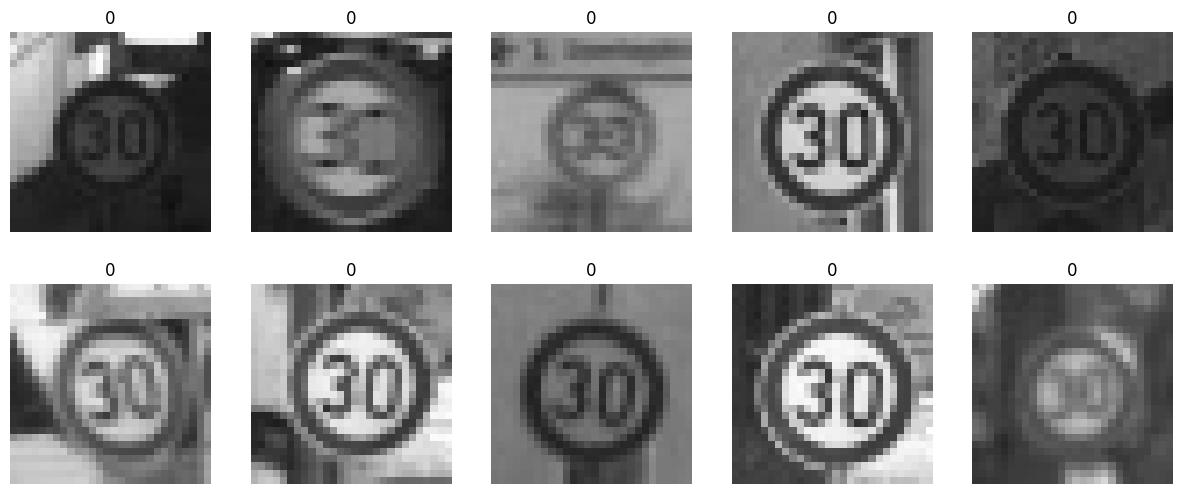

In [6]:
images_0, labels_0 = load_images(folder, 0)
visualize_images(images_0, labels_0)
print(f'Loaded {len(images_0)} images of class 0')


Loaded 2250 images of class 1


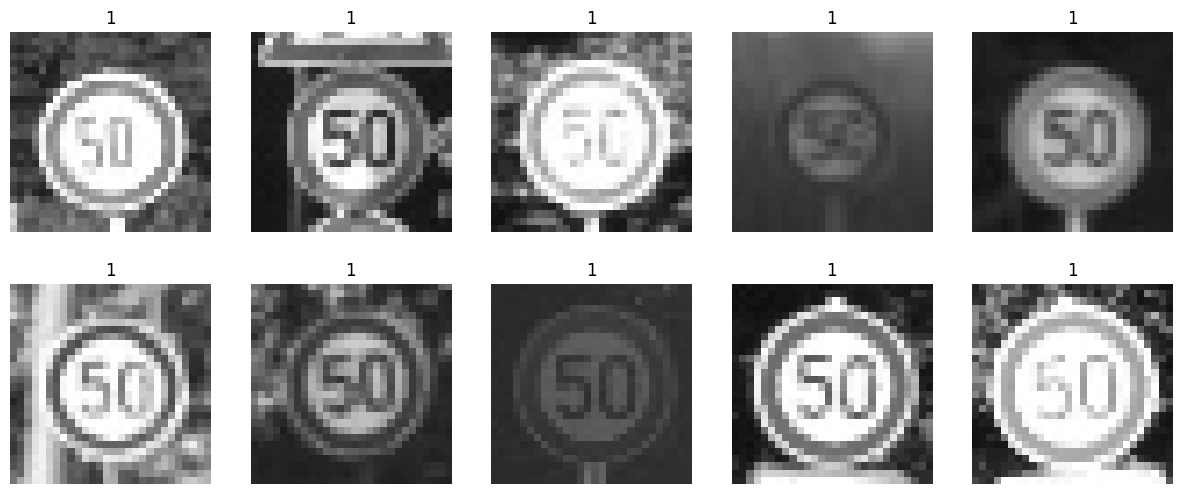

In [7]:
images_1, labels_1 = load_images(folder, 1)
visualize_images(images_1, labels_1)
print(f'Loaded {len(images_1)} images of class 1')


### Step 2
Run the training with one single neuron (as we did in the lecture). What accuracy can you achieve?

In [8]:
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

print('Images', images.shape)
print('Labels', labels.shape)

Images (4470, 28, 28)
Labels (4470,)


(4470, 784)


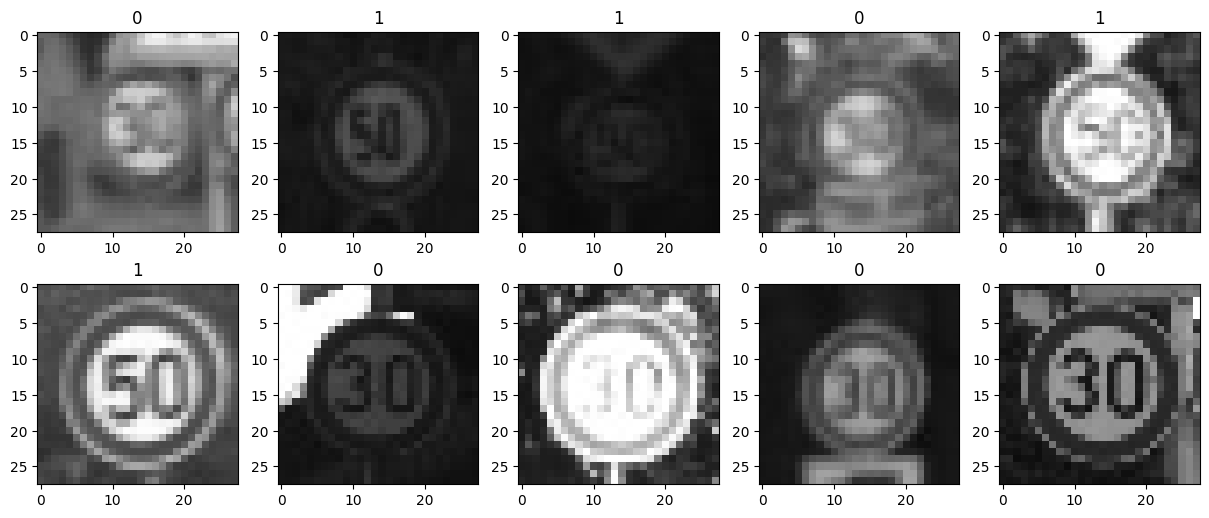

In [9]:
flatten_images = np.array([image.flatten() for image in images])/255
print(flatten_images.shape)

for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx])

In [10]:
inputs = Input(shape=(flatten_images.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

print(model.layers)

model.summary()

[<InputLayer name=input_layer, built=True>, <Dense name=dense, built=True>]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           785 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 785 (3.07 KB)

 Trainable params: 785 (3.07 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model.fit(flatten_images, labels, epochs=200, batch_size=32)


Epoch 1/200


2025-05-04 22:53:03.368411: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3740
Epoch 2/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2281
Epoch 3/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1896
Epoch 4/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1608
Epoch 5/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1396
Epoch 6/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1253
Epoch 7/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1194
Epoch 8/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1086
Epoch 9/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1064
Epoch 10/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0984
Epoch 11/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1040
Epoch 12/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0908
Epoch 13/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0899
Epoch 14/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0899
Epoch 15/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step -

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

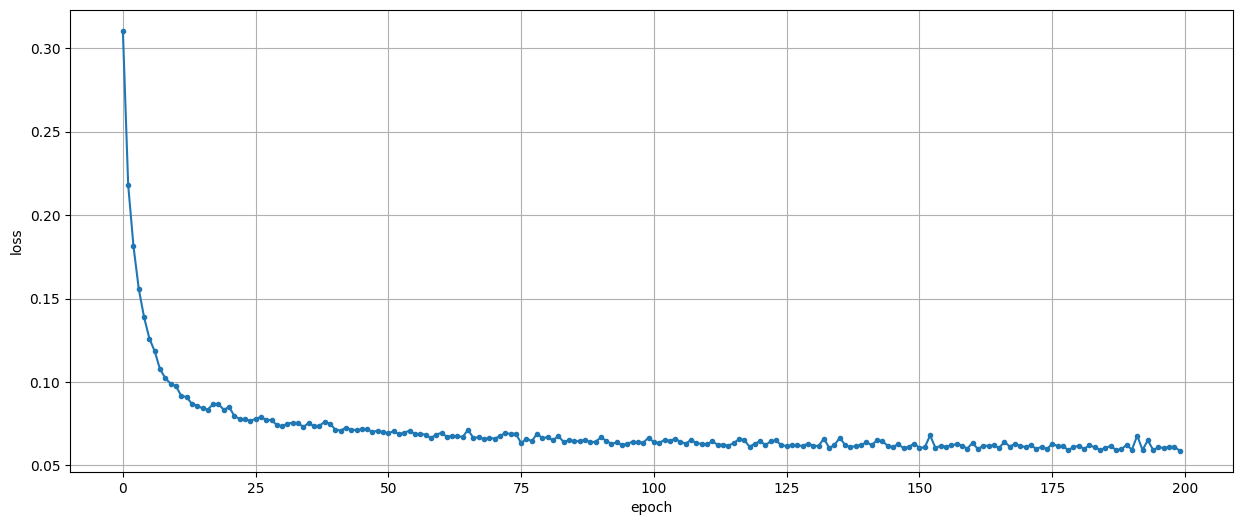

In [12]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.5273157] [0.5273157]


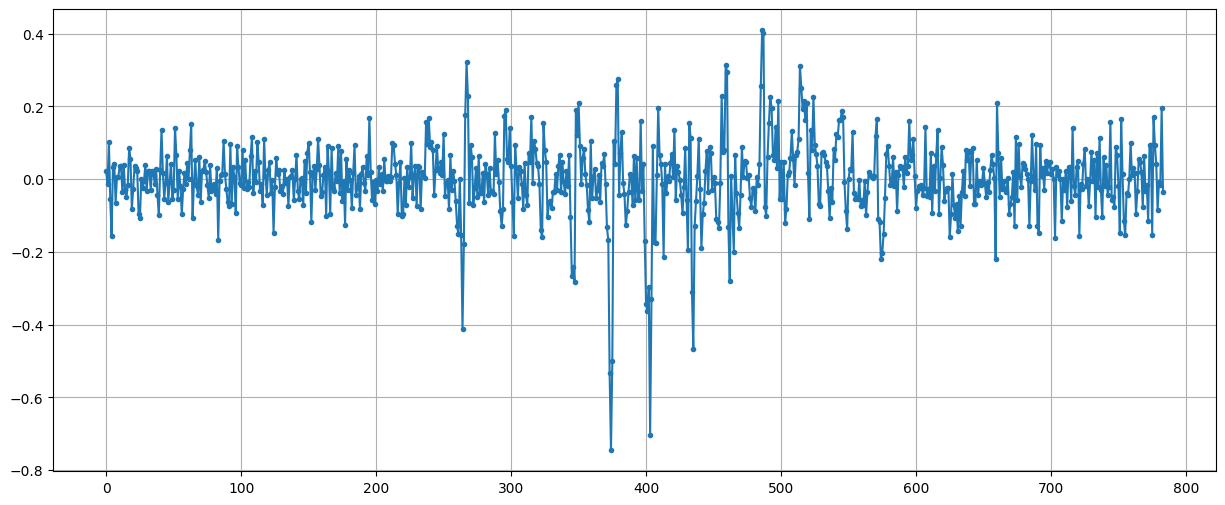

In [14]:
# Let's also have a looks at the learnt weights
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

In [16]:
idx = 50
pred = model.predict(flatten_images[idx:idx+1, ...])
print(pred, labels[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[0.47177625]] 0


In [17]:
# Run it on the entire dataset
predictions = model.predict(flatten_images).squeeze()
predictions = predictions > 0.5

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.9832214765100671


При простейшей сети с одним нейроном удалось получить точность 98,32%.

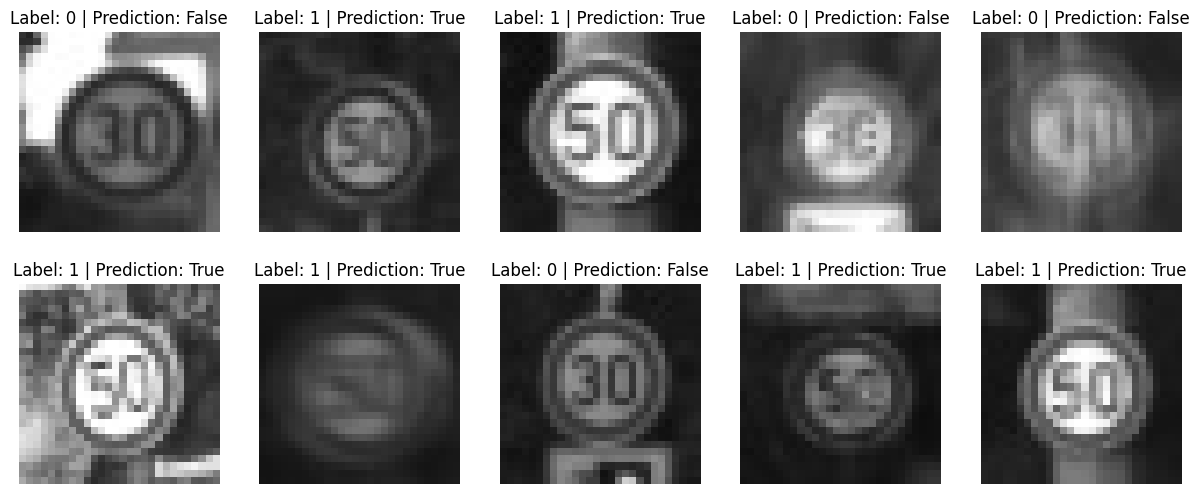

In [19]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

In [20]:
inputs = Input(shape=(flatten_images.shape[1],))
outputs = Dense(3, activation="linear")(inputs)
outputs = Dense(3, activation="linear")(outputs)
outputs = Dense(1, activation="linear")(outputs)
model = Model(inputs, outputs)

print(model.layers)

model.summary()

[<InputLayer name=input_layer_1, built=True>, <Dense name=dense_1, built=True>, <Dense name=dense_2, built=True>, <Dense name=dense_3, built=True>]


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         2,355 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,371 (9.26 KB)

 Trainable params: 2,371 (9.26 KB)

 Non-trainable params: 0 (0.00 B)

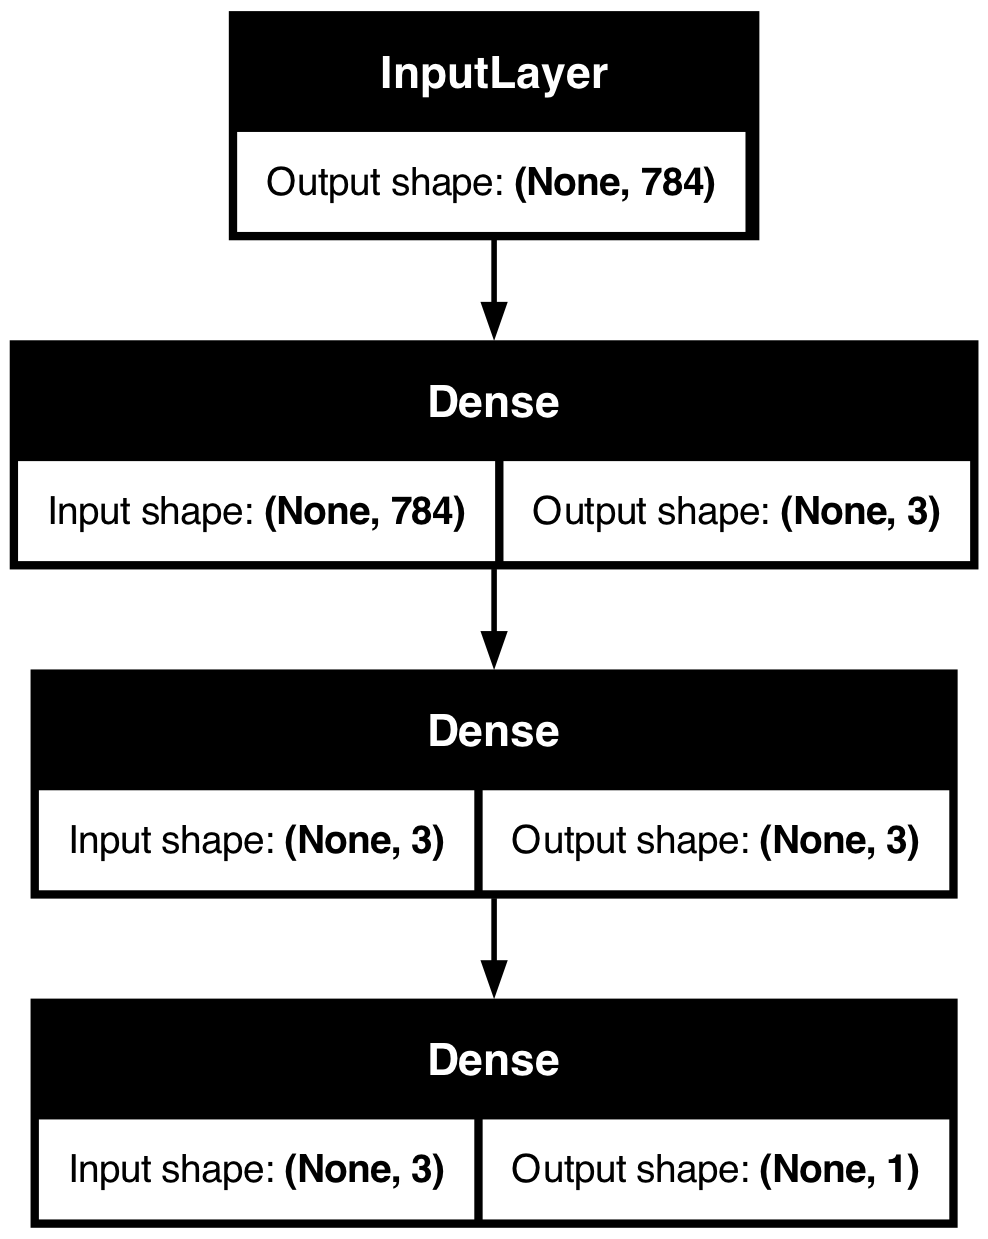

In [21]:
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True)

In [23]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

In [24]:
history = model.fit(flatten_images, labels, epochs=200, batch_size=32)

Epoch 1/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.3623
Epoch 2/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2099
Epoch 3/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1574
Epoch 4/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1299
Epoch 5/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1116
Epoch 6/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0992
Epoch 7/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0994
Epoch 8/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0935
Epoch 9/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0944
Epoch 10/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0931
Epoch 11/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0825
Epoch 12/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0836
Epoch 13/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0886
Epoch 14/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0826
Epoch 15/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

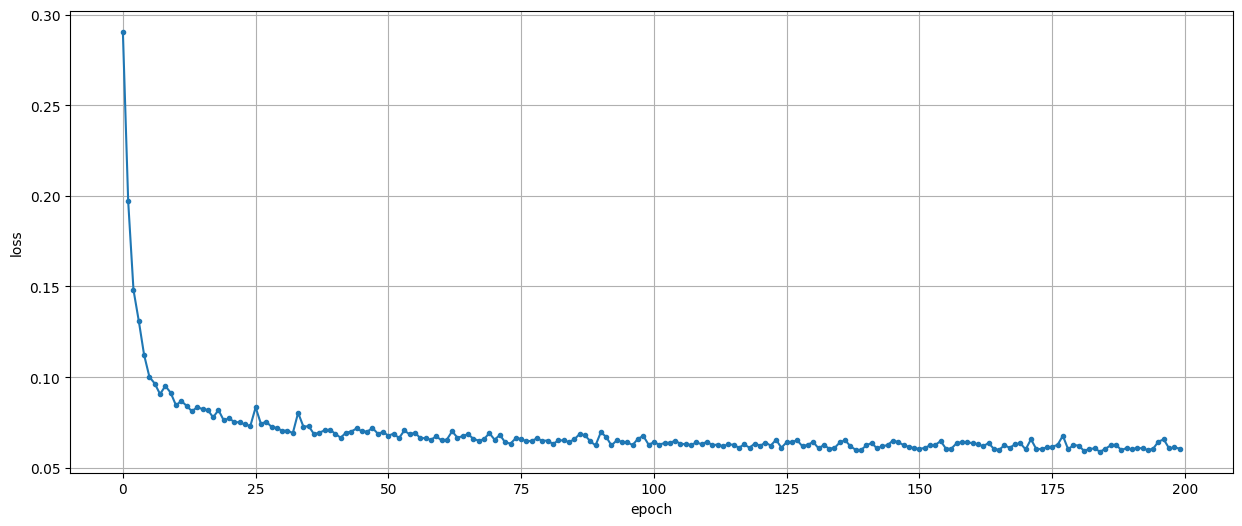

In [25]:
# Plot training history
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

In [26]:
# Run it on the entire dataset
predictions = model.predict(flatten_images).squeeze()
predictions = predictions > 0.5

correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.9812080536912752


При изменение конфигурации сети, при котором была добавлено два слоя по три нейрона, loss функция увеличилась с 
0.0585 до 0.0639. При этом точность распознавания уменьшилась с 98,32% до 98,12%.

In [27]:
inputs = Input(shape=(flatten_images.shape[1],))
outputs = Dense(5, activation="linear")(inputs)
outputs = Dense(5, activation="linear")(outputs)
outputs = Dense(1, activation="linear")(outputs)
model = Model(inputs, outputs)

print(model.layers)

model.summary()

[<InputLayer name=input_layer_2, built=True>, <Dense name=dense_4, built=True>, <Dense name=dense_5, built=True>, <Dense name=dense_6, built=True>]


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         3,925 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,961 (15.47 KB)

 Trainable params: 3,961 (15.47 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model.fit(flatten_images, labels, epochs=200, batch_size=32)

Epoch 1/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.6661
Epoch 2/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2378
Epoch 3/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1736
Epoch 4/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1402
Epoch 5/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1181
Epoch 6/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1141
Epoch 7/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1008
Epoch 8/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1001
Epoch 9/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0912
Epoch 10/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0930
Epoch 11/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0942
Epoch 12/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0936
Epoch 13/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0857
Epoch 14/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0828
Epoch 15/200
140/140 ━━━━━━━━━━━━━━━━━━━━ 1

In [29]:
# Run it on the entire dataset
predictions = model.predict(flatten_images).squeeze()
predictions = predictions > 0.5

correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.9796420581655481


При увеличении количества нейронов в двух слоях до 5 снижает процент правильного распознавания. 